In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("File uploaded:", file_name)

Saving sample (2).csv to sample (2).csv
File uploaded: sample (2).csv


In [3]:
import io

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1503, 513)


In [4]:
TARGET = "label"

features = [col for col in df.columns if col != TARGET]

X = df[features]
y = df[TARGET]

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Features:", len(features))
print("Target:", TARGET)
print("Feature matrix:", X.shape)

DATASET STRUCTURE
Rows: 1503
Columns: 513
Features: 512
Target: label
Feature matrix: (1503, 512)


In [5]:
print("Unique target values:")
print(sorted(y.unique()))

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Unique target values:
[np.int64(0), np.int64(1)]

Target distribution:
label
0    721
1    782
Name: count, dtype: int64


In [6]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

if missing_values.sum() > 0:
    display(missing_values[missing_values > 0])
else:
    print("No missing values found.")

Total missing values: 0
No missing values found.


In [7]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [8]:
numeric_features = X.select_dtypes(include=np.number).columns

infinite_count = np.isinf(X[numeric_features]).sum().sum()

print("Infinite values:", infinite_count)

Infinite values: 0


In [9]:
print("Data type distribution:")
print(df.dtypes.value_counts())

non_numeric = X.select_dtypes(exclude=np.number).columns.tolist()

print("\nNon-numeric feature columns:")
print(non_numeric)

Data type distribution:
int64    513
Name: count, dtype: int64

Non-numeric feature columns:
[]


In [10]:
constant_features = [
    col for col in features
    if X[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))

if constant_features:
    print("\nConstant features:")
    print(constant_features)
else:
    print("No constant features found.")

Number of constant features: 0
No constant features found.


In [11]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
byte_hist_0,1503.0,201968.996673,676847.674650,735.0,12593.5,46552.0,190569.5,18176557.0
byte_hist_1,1503.0,12517.879574,50481.365672,4.0,669.5,3093.0,11858.5,1154827.0
byte_hist_2,1503.0,7455.928809,22523.973821,1.0,353.0,1978.0,7466.5,324263.0
byte_hist_3,1503.0,6612.660679,18201.799821,1.0,334.0,1702.0,6606.5,238267.0
byte_hist_4,1503.0,8656.774451,23400.942820,5.0,450.0,2113.0,8864.0,478919.0
...,...,...,...,...,...,...,...,...
entropy_251,1503.0,66798.646041,358997.708245,0.0,0.0,1869.0,14880.5,6773498.0
entropy_252,1503.0,67163.876913,358947.307296,0.0,0.0,1824.0,15719.5,6771772.0
entropy_253,1503.0,66508.445110,358988.373592,0.0,0.0,1760.0,15032.0,6772794.0
entropy_254,1503.0,67527.801065,360606.542377,0.0,0.0,1755.0,15481.0,6781600.0


In [12]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    ((X < lower_bound) | (X > upper_bound))
    .sum()
    .sort_values(ascending=False)
)

outlier_percentage = (
    outlier_counts / len(X) * 100
).round(2)

outlier_summary = pd.DataFrame({
    "Outlier Count": outlier_counts,
    "Outlier Percentage": outlier_percentage
})

print("Top 20 features with potential outliers:")

display(outlier_summary.head(20))

Top 20 features with potential outliers:


,Outlier Count,Outlier Percentage
entropy_4,373,24.82
entropy_21,370,24.62
entropy_31,358,23.82
entropy_7,356,23.69
entropy_1,353,23.49
entropy_6,353,23.49
entropy_3,352,23.42
entropy_2,351,23.35
entropy_20,348,23.15
entropy_15,345,22.95


In [13]:
class_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

display(class_distribution)

,Count,Percentage
label,,
0,721,47.97
1,782,52.03


In [14]:
class_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

display(class_distribution)

,Count,Percentage
label,,
0,721,47.97
1,782,52.03


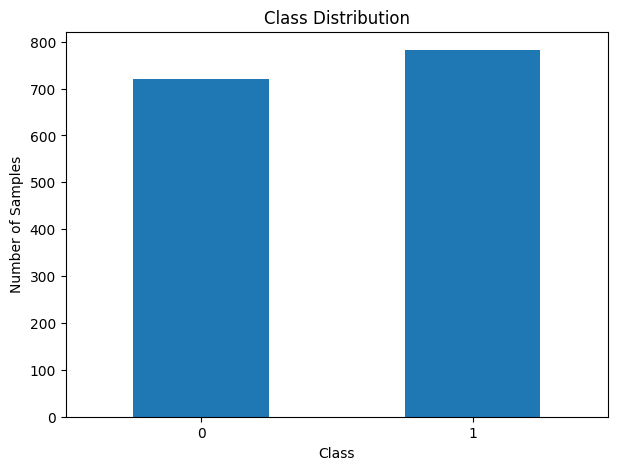

In [15]:
plt.figure(figsize=(7,5))

class_distribution["Count"].plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

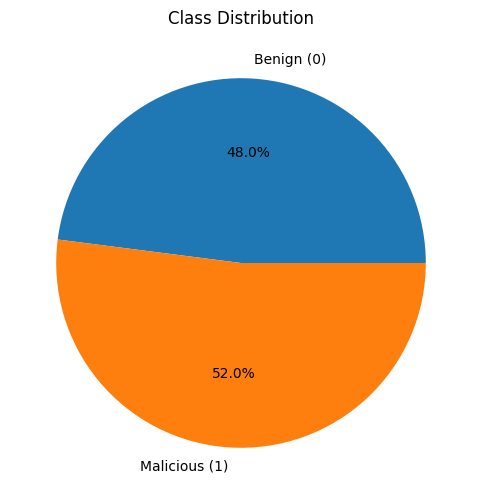

In [16]:
plt.figure(figsize=(6,6))

plt.pie(
    class_distribution["Count"],
    labels=["Benign (0)", "Malicious (1)"],
    autopct="%1.1f%%"
)

plt.title("Class Distribution")

plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts().sort_index())

print("\nTesting labels:")
print(y_test.value_counts().sort_index())

Training features: (1202, 512)
Testing features: (301, 512)

Training labels:
label
0    577
1    625
Name: count, dtype: int64

Testing labels:
label
0    144
1    157
Name: count, dtype: int64


In [18]:
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [19]:
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

X_test_processed = preprocessing_pipeline.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (1202, 512)
Processed testing shape: (301, 512)


In [20]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=features,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=features,
    index=X_test.index
)

print("Training processed DataFrame:", X_train_processed_df.shape)
print("Testing processed DataFrame:", X_test_processed_df.shape)

Training processed DataFrame: (1202, 512)
Testing processed DataFrame: (301, 512)


In [22]:
train_processed = X_train_processed_df.copy()
train_processed["label"] = y_train

test_processed = X_test_processed_df.copy()
test_processed["label"] = y_test

train_processed.to_csv(
    "train_processed.csv",
    index=False
)

test_processed.to_csv(
    "test_processed.csv",
    index=False
)

joblib.dump(
    preprocessing_pipeline,
    "preprocessing_pipeline.pkl"
)



['preprocessing_pipeline.pkl']

In [23]:
print("=" * 65)
print("DATA ANALYST — EXPLORATORY DATA ANALYSIS")
print("=" * 65)

print("Objective:")
print("Identify distributions, anomalies, correlations,")
print("feature relationships, and actionable insights.")

DATA ANALYST — EXPLORATORY DATA ANALYSIS
Objective:
Identify distributions, anomalies, correlations,
feature relationships, and actionable insights.


In [24]:
feature_variance = X.var().sort_values()

print("10 Features with Lowest Variance:")
display(feature_variance.head(10))

print("\n10 Features with Highest Variance:")
display(feature_variance.tail(10))

10 Features with Lowest Variance:


,0
entropy_11,35181.095716
entropy_42,77822.305313
entropy_58,118818.953380
entropy_26,136667.754076
entropy_27,166641.116563
entropy_43,302272.641428
entropy_37,336904.058550
entropy_4,391617.629897
entropy_21,394285.885239
entropy_5,403794.893354



10 Features with Highest Variance:


,0
entropy_244,1.294008e+11
entropy_242,1.297608e+11
entropy_247,1.299155e+11
entropy_254,1.300371e+11
entropy_241,1.305328e+11
entropy_255,1.333630e+11
entropy_240,1.412807e+11
entropy_0,1.853374e+11
byte_hist_0,4.581228e+11
entropy_16,5.301861e+11


In [25]:
feature_std = X.std().sort_values(ascending=False)

selected_distribution_features = (
    feature_std.head(6).index.tolist()
)

print("Features selected for distribution analysis:")
print(selected_distribution_features)

Features selected for distribution analysis:
['entropy_16', 'byte_hist_0', 'entropy_0', 'entropy_240', 'entropy_255', 'entropy_241']


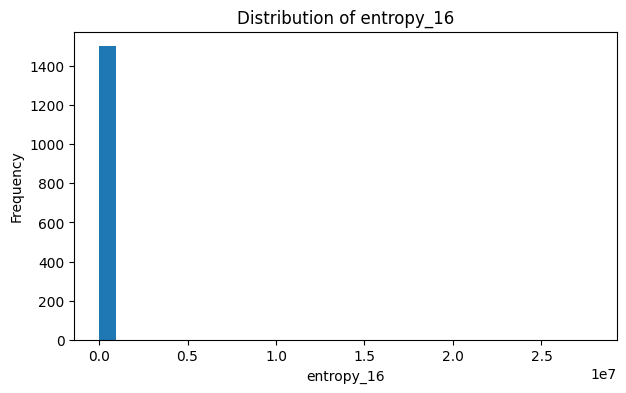

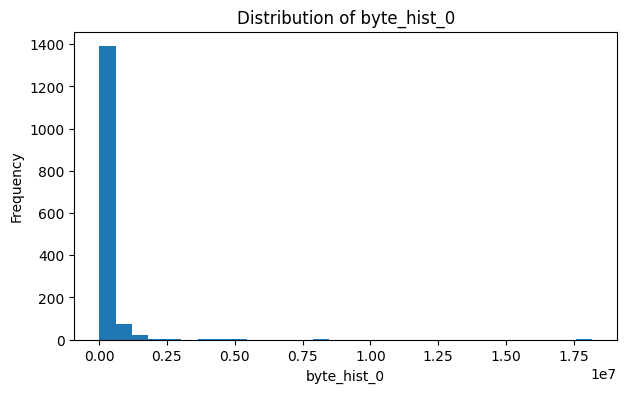

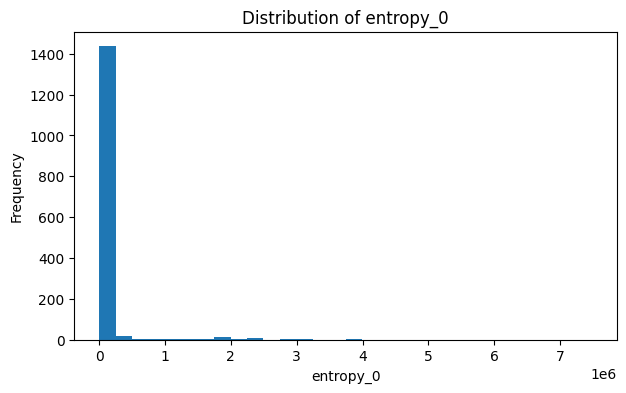

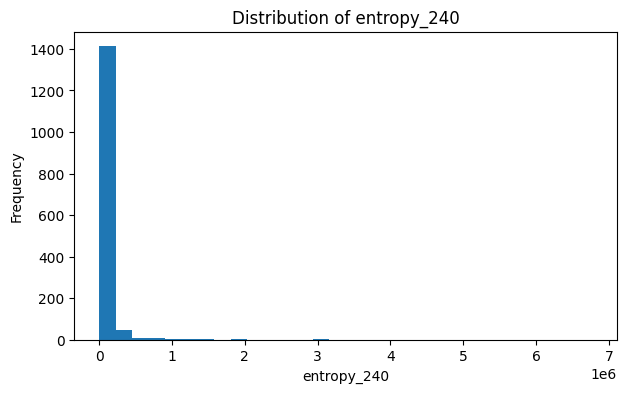

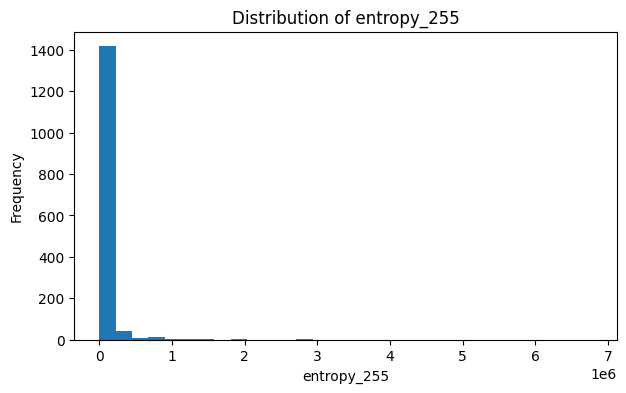

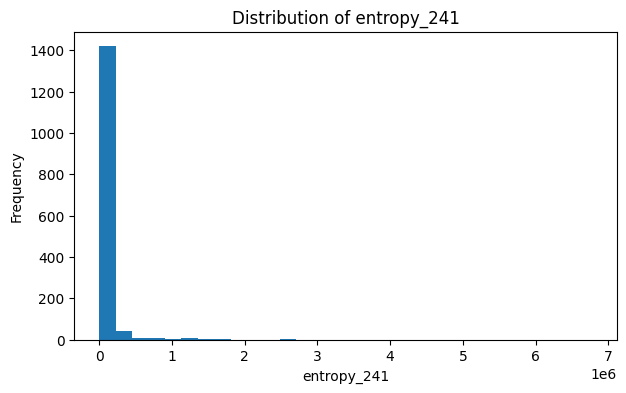

In [26]:
for feature in selected_distribution_features:

    plt.figure(figsize=(7,4))

    plt.hist(X[feature], bins=30)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

In [27]:
skewness = X.skew().sort_values()

print("Most negatively skewed features:")
display(skewness.head(10))

print("\nMost positively skewed features:")
display(skewness.tail(10))

Most negatively skewed features:


,0
byte_hist_32,6.418707
byte_hist_117,6.745754
entropy_164,7.250862
byte_hist_86,7.255813
byte_hist_3,7.340222
byte_hist_16,7.384131
byte_hist_50,7.418202
byte_hist_8,7.435817
entropy_187,7.442987
entropy_48,7.498769



Most positively skewed features:


,0
entropy_19,36.316153
entropy_204,36.377146
entropy_39,36.593621
entropy_32,36.903661
entropy_101,37.008000
entropy_35,37.235727
entropy_7,37.322727
entropy_16,37.426078
entropy_100,37.787658
entropy_28,38.028384


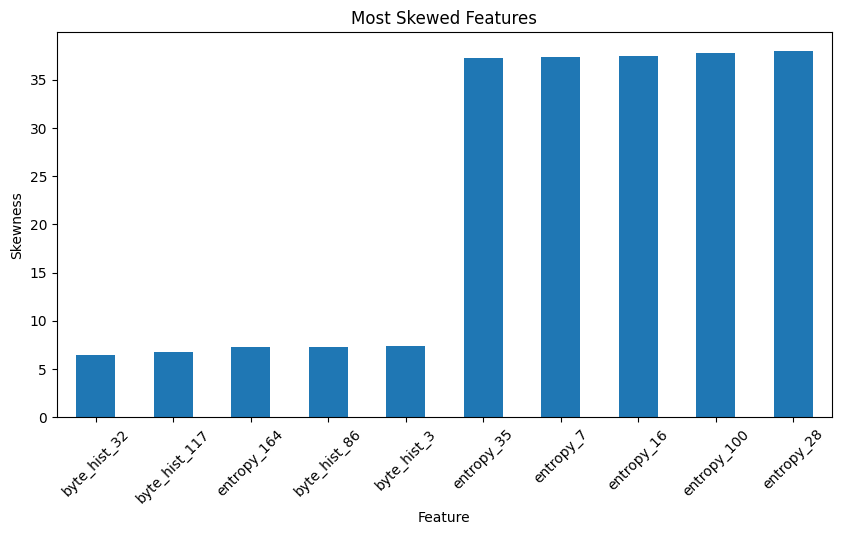

In [28]:
top_skewed = pd.concat([
    skewness.head(5),
    skewness.tail(5)
])

plt.figure(figsize=(10,5))

top_skewed.plot(kind="bar")

plt.title("Most Skewed Features")
plt.xlabel("Feature")
plt.ylabel("Skewness")

plt.xticks(rotation=45)

plt.show()

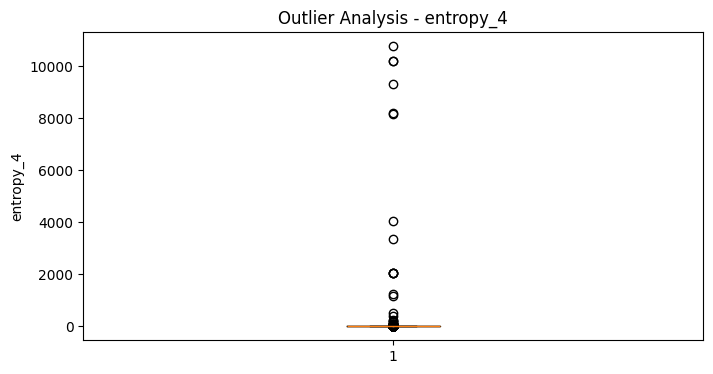

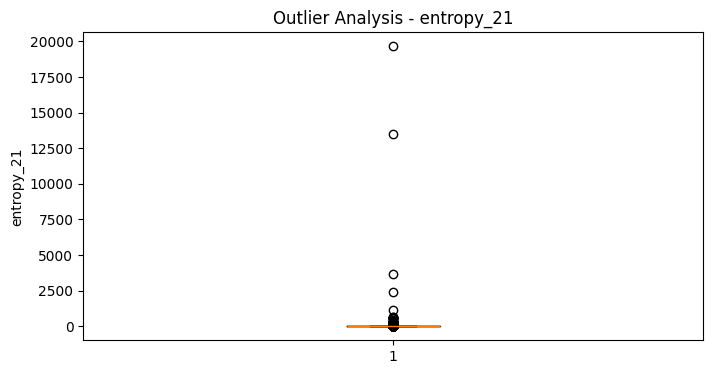

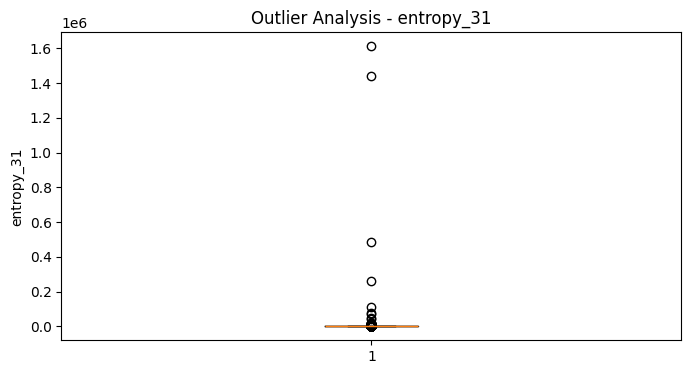

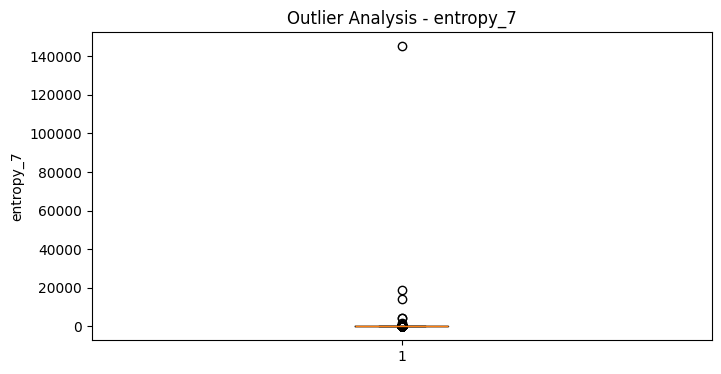

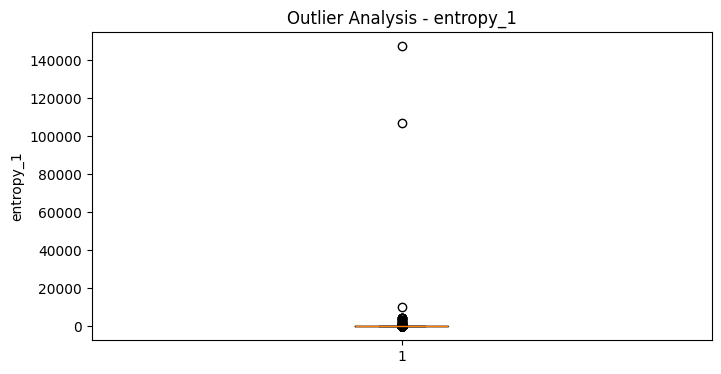

In [29]:
top_outlier_features = outlier_counts.head(5).index

for feature in top_outlier_features:

    plt.figure(figsize=(8,4))

    plt.boxplot(X[feature].dropna())

    plt.title(f"Outlier Analysis - {feature}")
    plt.ylabel(feature)

    plt.show()

In [30]:
correlations = X.corrwith(y)

correlation_summary = pd.DataFrame({
    "Feature": correlations.index,
    "Correlation": correlations.values,
    "Absolute Correlation": correlations.abs().values
})

correlation_summary = correlation_summary.sort_values(
    "Absolute Correlation",
    ascending=False
)

display(correlation_summary.head(20))

,Feature,Correlation,Absolute Correlation
306,entropy_50,0.126824,0.126824
304,entropy_48,0.120774,0.120774
2,byte_hist_2,-0.115130,0.115130
375,entropy_119,-0.114756,0.114756
374,entropy_118,-0.114373,0.114373
373,entropy_117,-0.113200,0.113200
10,byte_hist_10,-0.112735,0.112735
16,byte_hist_16,-0.111243,0.111243
468,entropy_212,-0.107949,0.107949
15,byte_hist_15,-0.105996,0.105996


In [31]:
print("Strongest Positive Correlations:")

display(
    correlation_summary
    .sort_values("Correlation", ascending=False)
    .head(10)
)

print("\nStrongest Negative Correlations:")

display(
    correlation_summary
    .sort_values("Correlation", ascending=True)
    .head(10)
)

Strongest Positive Correlations:


,Feature,Correlation,Absolute Correlation
306,entropy_50,0.126824,0.126824
304,entropy_48,0.120774,0.120774
419,entropy_163,0.082093,0.082093
334,entropy_78,0.077635,0.077635
423,entropy_167,0.073852,0.073852
418,entropy_162,0.073708,0.073708
421,entropy_165,0.071634,0.071634
354,entropy_98,0.061388,0.061388
308,entropy_52,0.060876,0.060876
486,entropy_230,0.060400,0.060400



Strongest Negative Correlations:


,Feature,Correlation,Absolute Correlation
2,byte_hist_2,-0.115130,0.115130
375,entropy_119,-0.114756,0.114756
374,entropy_118,-0.114373,0.114373
373,entropy_117,-0.113200,0.113200
10,byte_hist_10,-0.112735,0.112735
16,byte_hist_16,-0.111243,0.111243
468,entropy_212,-0.107949,0.107949
15,byte_hist_15,-0.105996,0.105996
384,entropy_128,-0.104125,0.104125
391,entropy_135,-0.103311,0.103311


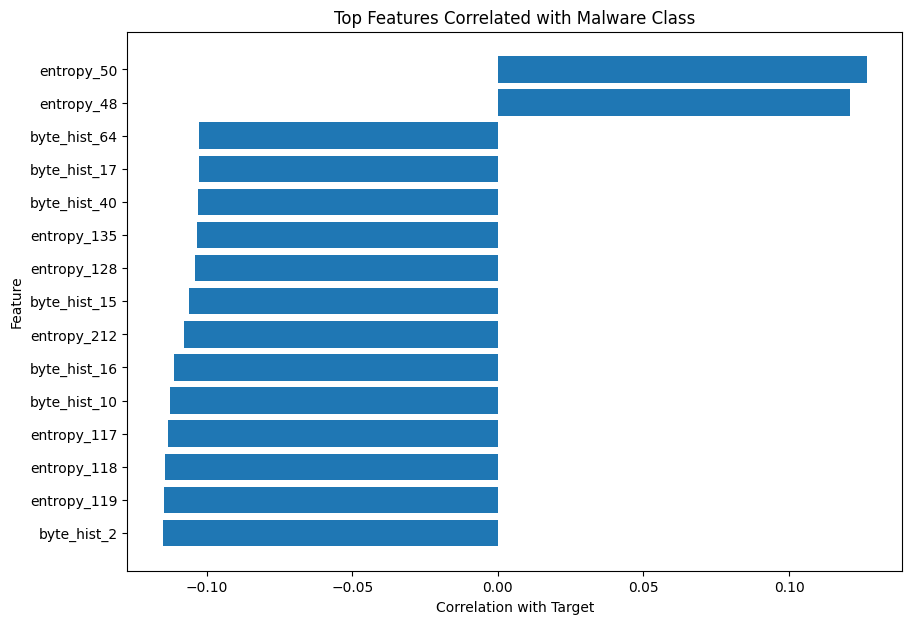

In [32]:
top_corr = (
    correlation_summary
    .head(15)
    .sort_values("Correlation")
)

plt.figure(figsize=(10,7))

plt.barh(
    top_corr["Feature"],
    top_corr["Correlation"]
)

plt.title("Top Features Correlated with Malware Class")
plt.xlabel("Correlation with Target")
plt.ylabel("Feature")

plt.show()

In [33]:
top_10_features = correlation_summary.head(10)["Feature"].tolist()

feature_corr = X[top_10_features].corr()

interaction_pairs = []

for i in range(len(feature_corr.columns)):

    for j in range(i + 1, len(feature_corr.columns)):

        feature_1 = feature_corr.columns[i]
        feature_2 = feature_corr.columns[j]

        correlation_value = feature_corr.iloc[i, j]

        interaction_pairs.append({
            "Feature 1": feature_1,
            "Feature 2": feature_2,
            "Correlation": correlation_value,
            "Absolute Correlation": abs(correlation_value)
        })

interaction_summary = pd.DataFrame(
    interaction_pairs
).sort_values(
    "Absolute Correlation",
    ascending=False
)

display(interaction_summary.head(15))

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,entropy_50,entropy_48,0.984540,0.984540
24,entropy_119,entropy_118,0.982291,0.982291
20,byte_hist_2,byte_hist_10,0.908815,0.908815
43,byte_hist_16,byte_hist_15,0.859258,0.859258
21,byte_hist_2,byte_hist_16,0.830880,0.830880
25,entropy_119,entropy_117,0.813075,0.813075
30,entropy_118,entropy_117,0.801030,0.801030
23,byte_hist_2,byte_hist_15,0.799937,0.799937
39,byte_hist_10,byte_hist_16,0.776081,0.776081
41,byte_hist_10,byte_hist_15,0.749569,0.749569


Strongest feature interaction:
entropy_50 vs entropy_48
Correlation: 0.98454


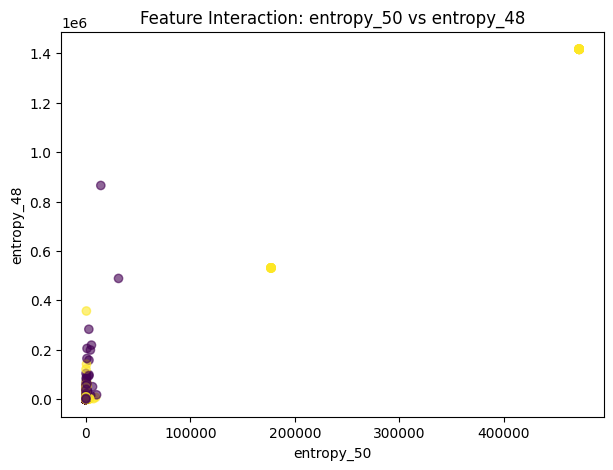

In [34]:
strongest_pair = interaction_summary.iloc[0]

feature_1 = strongest_pair["Feature 1"]
feature_2 = strongest_pair["Feature 2"]

print("Strongest feature interaction:")
print(feature_1, "vs", feature_2)

print(
    "Correlation:",
    round(strongest_pair["Correlation"], 6)
)

plt.figure(figsize=(7,5))

plt.scatter(
    X[feature_1],
    X[feature_2],
    c=y,
    alpha=0.6
)

plt.xlabel(feature_1)
plt.ylabel(feature_2)

plt.title(
    f"Feature Interaction: {feature_1} vs {feature_2}"
)

plt.show()

In [35]:
top_class_features = (
    correlation_summary.head(10)["Feature"].tolist()
)

class_means = (
    df.groupby(TARGET)[top_class_features]
    .mean()
    .T
)

display(class_means)

label,0,1
entropy_50,165.796117,14577.570332
entropy_48,7789.201110,49477.514066
byte_hist_2,10155.694868,4966.758312
entropy_119,8873.257975,2957.388747
entropy_118,17343.441054,5678.943734
entropy_117,2593.514563,952.216113
byte_hist_10,6284.216366,2926.281330
byte_hist_16,9568.144244,5012.470588
entropy_212,47307.083218,16668.487212
byte_hist_15,9017.285714,4662.609974


<Figure size 700x500 with 0 Axes>

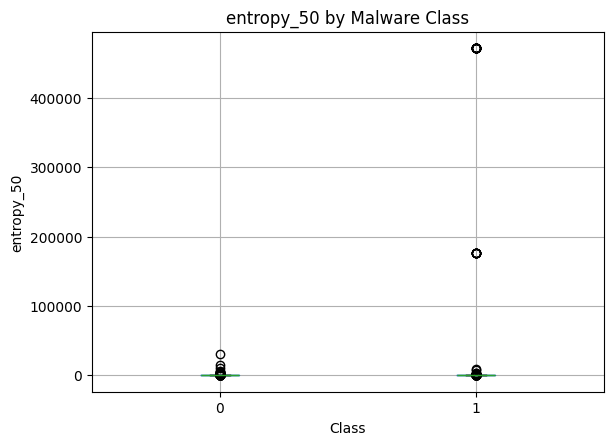

<Figure size 700x500 with 0 Axes>

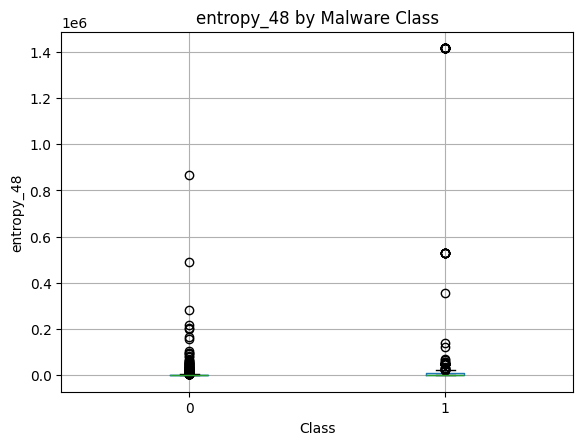

<Figure size 700x500 with 0 Axes>

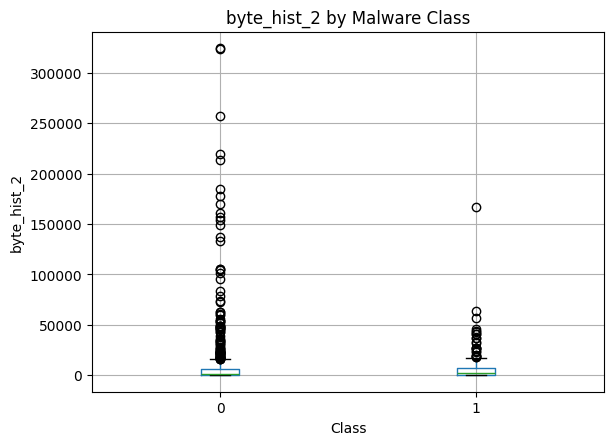

<Figure size 700x500 with 0 Axes>

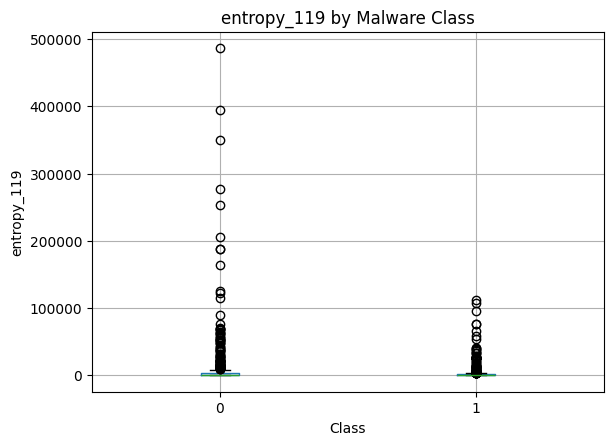

<Figure size 700x500 with 0 Axes>

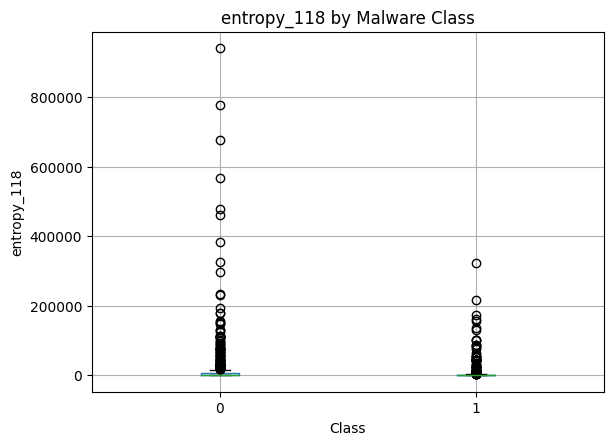

In [36]:
for feature in top_class_features[:5]:

    plt.figure(figsize=(7,5))

    df.boxplot(
        column=feature,
        by=TARGET
    )

    plt.title(f"{feature} by Malware Class")
    plt.suptitle("")

    plt.xlabel("Class")
    plt.ylabel(feature)

    plt.show()

In [37]:
class_0 = df[df[TARGET] == 0]
class_1 = df[df[TARGET] == 1]

separation_results = []

for feature in features:

    mean_0 = class_0[feature].mean()
    mean_1 = class_1[feature].mean()

    std_0 = class_0[feature].std()
    std_1 = class_1[feature].std()

    pooled_std = np.sqrt(
        (std_0**2 + std_1**2) / 2
    )

    if pooled_std != 0:

        separation = (
            abs(mean_1 - mean_0) / pooled_std
        )

    else:

        separation = 0

    separation_results.append({
        "Feature": feature,
        "Class 0 Mean": mean_0,
        "Class 1 Mean": mean_1,
        "Mean Difference": abs(mean_1 - mean_0),
        "Standardized Separation": separation
    })

separation_df = pd.DataFrame(
    separation_results
).sort_values(
    "Standardized Separation",
    ascending=False
)

display(separation_df.head(20))

,Feature,Class 0 Mean,Class 1 Mean,Mean Difference,Standardized Separation
306,entropy_50,165.796117,14577.570332,14411.774216,0.260894
304,entropy_48,7789.201110,49477.514066,41688.312957,0.247947
2,byte_hist_2,10155.694868,4966.758312,5188.936556,0.227778
375,entropy_119,8873.257975,2957.388747,5915.869228,0.227041
374,entropy_118,17343.441054,5678.943734,11664.497320,0.226423
373,entropy_117,2593.514563,952.216113,1641.298451,0.223992
10,byte_hist_10,6284.216366,2926.281330,3357.935036,0.222940
16,byte_hist_16,9568.144244,5012.470588,4555.673656,0.219912
468,entropy_212,47307.083218,16668.487212,30638.596005,0.212930
15,byte_hist_15,9017.285714,4662.609974,4354.675740,0.209339


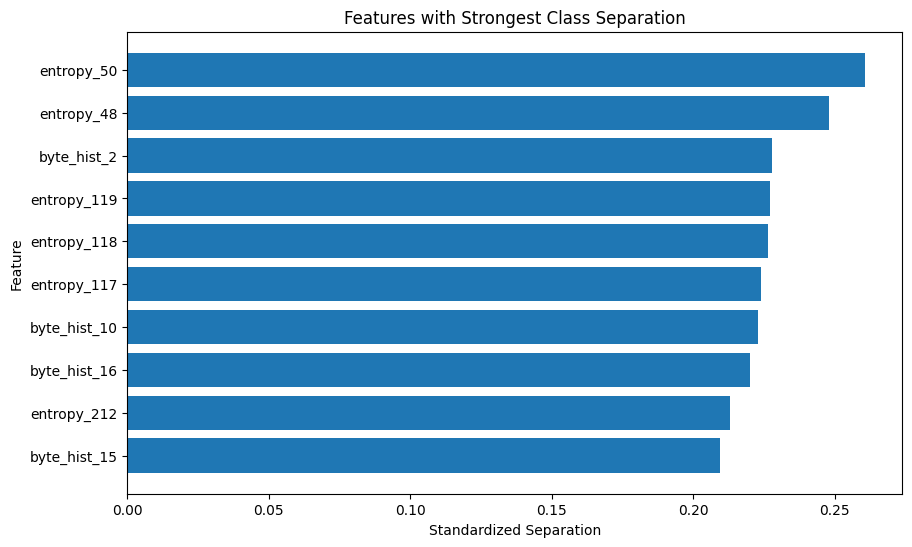

In [38]:
top_separation = separation_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_separation["Feature"],
    top_separation["Standardized Separation"]
)

plt.title("Features with Strongest Class Separation")
plt.xlabel("Standardized Separation")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [39]:
print("=" * 65)
print("FEATURE SELECTION — MUTUAL INFORMATION")
print("=" * 65)

# Calculate mutual information using TRAINING DATA ONLY
mi_scores = mutual_info_classif(
    X_train_processed_df,
    y_train,
    random_state=42
)

mi_summary = pd.DataFrame({
    "Feature": features,
    "Mutual Information": mi_scores
})

mi_summary = mi_summary.sort_values(
    "Mutual Information",
    ascending=False
)

print("Top 20 features based on Mutual Information:")

display(mi_summary.head(20))

FEATURE SELECTION — MUTUAL INFORMATION
Top 20 features based on Mutual Information:


,Feature,Mutual Information
501,entropy_245,0.213165
511,entropy_255,0.203279
62,byte_hist_62,0.202095
510,entropy_254,0.199023
498,entropy_242,0.196582
249,byte_hist_249,0.195804
504,entropy_248,0.192610
255,byte_hist_255,0.191092
251,byte_hist_251,0.188609
15,byte_hist_15,0.188606


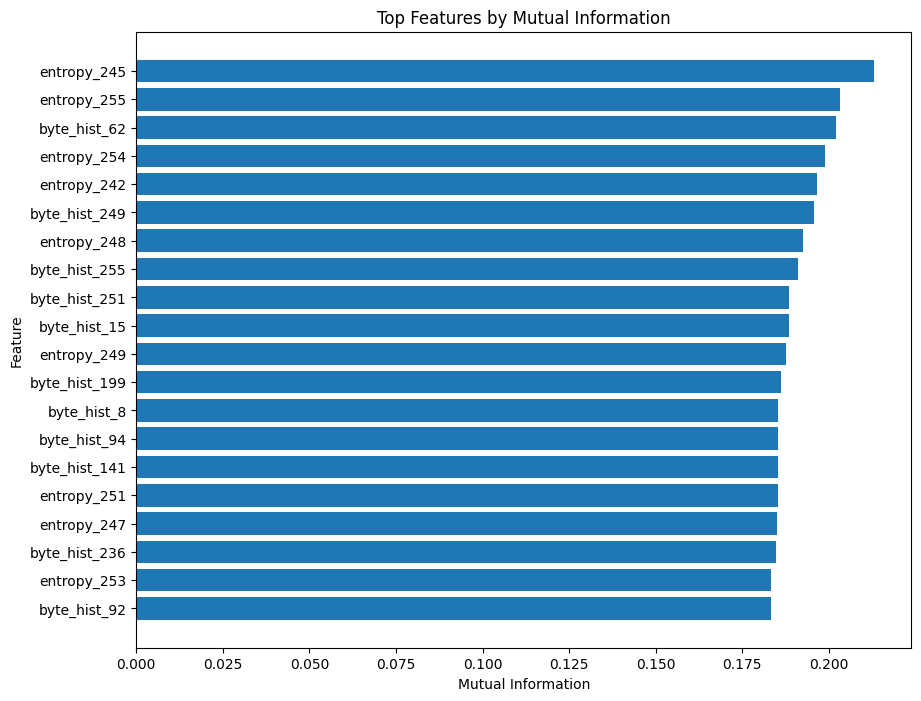

In [40]:
top_mi = mi_summary.head(20).sort_values(
    "Mutual Information"
)

plt.figure(figsize=(10,8))

plt.barh(
    top_mi["Feature"],
    top_mi["Mutual Information"]
)

plt.title("Top Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.show()

In [41]:
K_FEATURES = 50

selected_features_mi = (
    mi_summary
    .head(K_FEATURES)["Feature"]
    .tolist()
)

print("Number of selected candidate features:", len(selected_features_mi))

print("\nSelected features:")

for i, feature in enumerate(selected_features_mi, 1):
    print(f"{i}. {feature}")

Number of selected candidate features: 50

Selected features:
1. entropy_245
2. entropy_255
3. byte_hist_62
4. entropy_254
5. entropy_242
6. byte_hist_249
7. entropy_248
8. byte_hist_255
9. byte_hist_251
10. byte_hist_15
11. entropy_249
12. byte_hist_199
13. byte_hist_8
14. byte_hist_94
15. byte_hist_141
16. entropy_251
17. entropy_247
18. byte_hist_236
19. entropy_253
20. byte_hist_92
21. byte_hist_40
22. entropy_241
23. entropy_250
24. byte_hist_64
25. byte_hist_195
26. byte_hist_240
27. entropy_244
28. byte_hist_204
29. entropy_220
30. entropy_246
31. byte_hist_28
32. byte_hist_190
33. byte_hist_217
34. byte_hist_174
35. byte_hist_59
36. byte_hist_247
37. byte_hist_242
38. entropy_215
39. entropy_252
40. byte_hist_201
41. byte_hist_152
42. byte_hist_20
43. byte_hist_0
44. byte_hist_136
45. byte_hist_216
46. byte_hist_18
47. byte_hist_184
48. byte_hist_153
49. byte_hist_36
50. byte_hist_134


In [42]:
selected_corr = (
    X_train_processed_df[selected_features_mi]
    .corr()
    .abs()
)

upper_triangle = selected_corr.where(
    np.triu(
        np.ones(selected_corr.shape),
        k=1
    ).astype(bool)
)

redundant_pairs = []

for column in upper_triangle.columns:

    for row in upper_triangle.index:

        value = upper_triangle.loc[row, column]

        if pd.notna(value) and value >= 0.95:

            redundant_pairs.append({
                "Feature 1": row,
                "Feature 2": column,
                "Absolute Correlation": value
            })

redundant_pairs_df = pd.DataFrame(
    redundant_pairs
).sort_values(
    "Absolute Correlation",
    ascending=False
)

print("Highly correlated feature pairs (|r| >= 0.95):")

display(redundant_pairs_df.head(20))

Highly correlated feature pairs (|r| >= 0.95):


,Feature 1,Feature 2,Absolute Correlation
74,entropy_251,entropy_253,0.999905
253,entropy_253,entropy_252,0.999847
251,entropy_251,entropy_252,0.999798
116,entropy_249,entropy_244,0.999791
247,entropy_248,entropy_252,0.999749
64,entropy_245,entropy_253,0.999733
43,entropy_245,entropy_251,0.999724
6,entropy_245,entropy_242,0.999686
241,entropy_245,entropy_252,0.999680
122,entropy_250,entropy_244,0.999666


In [43]:
features_after_redundancy = selected_features_mi.copy()

for _, row in redundant_pairs_df.iterrows():

    feature_1 = row["Feature 1"]
    feature_2 = row["Feature 2"]

    if feature_1 not in features_after_redundancy:
        continue

    if feature_2 not in features_after_redundancy:
        continue

    mi_1 = mi_summary.loc[
        mi_summary["Feature"] == feature_1,
        "Mutual Information"
    ].iloc[0]

    mi_2 = mi_summary.loc[
        mi_summary["Feature"] == feature_2,
        "Mutual Information"
    ].iloc[0]

    if mi_1 >= mi_2:

        features_after_redundancy.remove(feature_2)

    else:

        features_after_redundancy.remove(feature_1)

print(
    "Features before redundancy removal:",
    len(selected_features_mi)
)

print(
    "Features after redundancy removal:",
    len(features_after_redundancy)
)

Features before redundancy removal: 50
Features after redundancy removal: 17


In [44]:
final_selected_features = features_after_redundancy

feature_selection_summary = mi_summary[
    mi_summary["Feature"].isin(final_selected_features)
].copy()

feature_selection_summary = (
    feature_selection_summary
    .sort_values(
        "Mutual Information",
        ascending=False
    )
)

print("FINAL SELECTED FEATURES")
print("=" * 50)

for i, feature in enumerate(
    final_selected_features,
    1
):
    print(f"{i}. {feature}")

print(
    "\nFinal number of selected features:",
    len(final_selected_features)
)

FINAL SELECTED FEATURES
1. entropy_245
2. byte_hist_255
3. byte_hist_15
4. byte_hist_199
5. byte_hist_8
6. byte_hist_141
7. byte_hist_236
8. byte_hist_92
9. byte_hist_40
10. byte_hist_64
11. byte_hist_204
12. entropy_220
13. entropy_215
14. byte_hist_0
15. byte_hist_136
16. byte_hist_216
17. byte_hist_36

Final number of selected features: 17


In [45]:
X_train_selected = X_train_processed_df[
    final_selected_features
].copy()

X_test_selected = X_test_processed_df[
    final_selected_features
].copy()

train_selected = X_train_selected.copy()
train_selected["label"] = y_train

test_selected = X_test_selected.copy()
test_selected["label"] = y_test

print("Selected training dataset:", train_selected.shape)
print("Selected testing dataset:", test_selected.shape)

Selected training dataset: (1202, 18)
Selected testing dataset: (301, 18)


In [46]:
train_selected.to_csv(
    "train_selected_features.csv",
    index=False
)

test_selected.to_csv(
    "test_selected_features.csv",
    index=False
)

feature_selection_summary.to_csv(
    "feature_selection_summary.csv",
    index=False
)

pd.DataFrame({
    "Selected Feature": final_selected_features
}).to_csv(
    "selected_features.csv",
    index=False
)

redundant_pairs_df.to_csv(
    "feature_redundancy_pairs.csv",
    index=False
)

print("Feature selection outputs saved successfully.")

Feature selection outputs saved successfully.


In [47]:
print("=" * 65)
print("TOP 3 DATA ANALYST INSIGHTS")
print("=" * 65)

# Insight 1
strongest_correlation = correlation_summary.iloc[0]

print("\nINSIGHT 1 — STRONGEST TARGET CORRELATION")
print(
    f"Feature: {strongest_correlation['Feature']}"
)
print(
    f"Correlation: {strongest_correlation['Correlation']:.6f}"
)

# Insight 2
strongest_interaction = interaction_summary.iloc[0]

print("\nINSIGHT 2 — STRONGEST FEATURE INTERACTION")
print(
    f"Feature 1: {strongest_interaction['Feature 1']}"
)
print(
    f"Feature 2: {strongest_interaction['Feature 2']}"
)
print(
    f"Correlation: {strongest_interaction['Correlation']:.6f}"
)

# Insight 3
strongest_separation = separation_df.iloc[0]

print("\nINSIGHT 3 — STRONGEST CLASS SEPARATION")
print(
    f"Feature: {strongest_separation['Feature']}"
)
print(
    f"Class 0 Mean: {strongest_separation['Class 0 Mean']:.4f}"
)
print(
    f"Class 1 Mean: {strongest_separation['Class 1 Mean']:.4f}"
)
print(
    f"Standardized Separation: "
    f"{strongest_separation['Standardized Separation']:.4f}"
)

TOP 3 DATA ANALYST INSIGHTS

INSIGHT 1 — STRONGEST TARGET CORRELATION
Feature: entropy_50
Correlation: 0.126824

INSIGHT 2 — STRONGEST FEATURE INTERACTION
Feature 1: entropy_50
Feature 2: entropy_48
Correlation: 0.984540

INSIGHT 3 — STRONGEST CLASS SEPARATION
Feature: entropy_50
Class 0 Mean: 165.7961
Class 1 Mean: 14577.5703
Standardized Separation: 0.2609


In [48]:
print("=" * 65)
print("DATA ANALYST HANDOFF SUMMARY")
print("=" * 65)

print("\nDataset:")
print(f"- Samples: {df.shape[0]}")
print(f"- Original features: {len(features)}")

print("\nClass Distribution:")

for class_value, row in class_distribution.iterrows():

    print(
        f"- Class {class_value}: "
        f"{int(row['Count'])} samples "
        f"({row['Percentage']:.2f}%)"
    )

print("\nEDA Findings:")

print(
    f"- Strongest target correlation: "
    f"{strongest_correlation['Feature']} "
    f"({strongest_correlation['Correlation']:.4f})"
)

print(
    f"- Strongest feature interaction: "
    f"{strongest_interaction['Feature 1']} ↔ "
    f"{strongest_interaction['Feature 2']} "
    f"({strongest_interaction['Correlation']:.4f})"
)

print(
    f"- Strongest class separation: "
    f"{strongest_separation['Feature']} "
    f"({strongest_separation['Standardized Separation']:.4f})"
)

print("\nFeature Selection:")

print(
    f"- Candidate features from Mutual Information: "
    f"{K_FEATURES}"
)

print(
    f"- Final selected features after redundancy check: "
    f"{len(final_selected_features)}"
)

print("\nData Analyst work completed.")
print("Ready for handoff to the Data Scientist.")

DATA ANALYST HANDOFF SUMMARY

Dataset:
- Samples: 1503
- Original features: 512

Class Distribution:
- Class 0: 721 samples (47.97%)
- Class 1: 782 samples (52.03%)

EDA Findings:
- Strongest target correlation: entropy_50 (0.1268)
- Strongest feature interaction: entropy_50 ↔ entropy_48 (0.9845)
- Strongest class separation: entropy_50 (0.2609)

Feature Selection:
- Candidate features from Mutual Information: 50
- Final selected features after redundancy check: 17

Data Analyst work completed.
Ready for handoff to the Data Scientist.


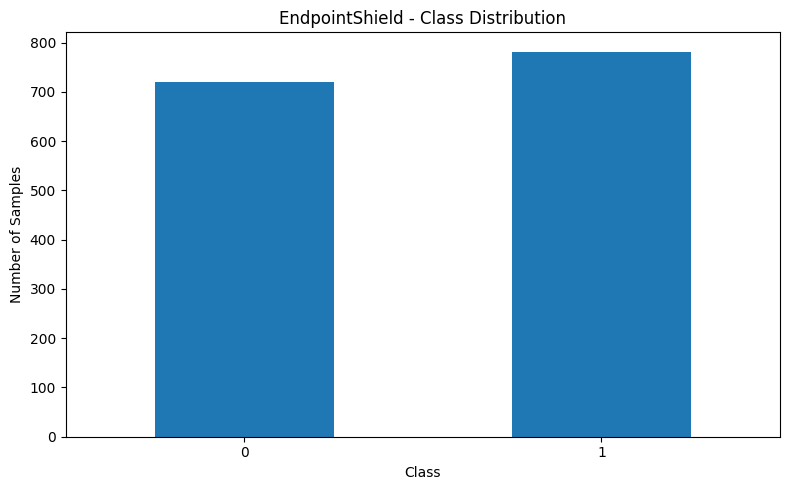

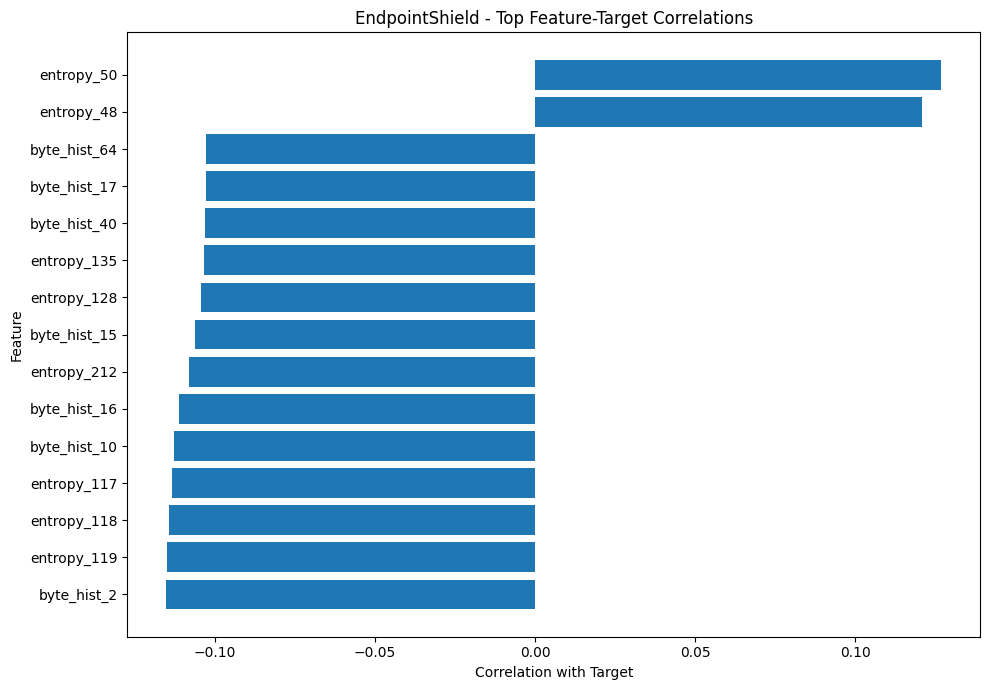

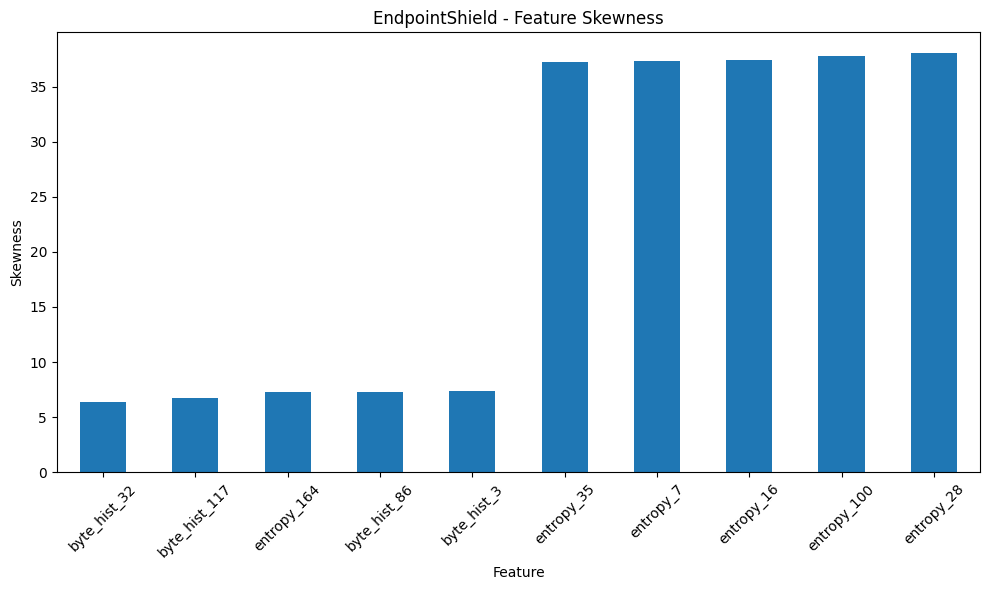

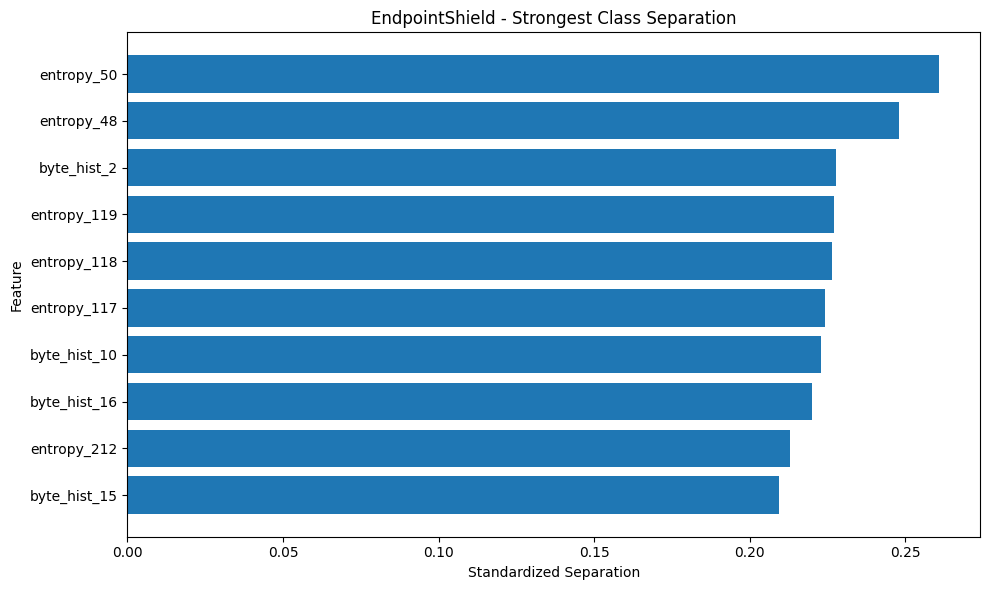

ENDPOINTSHIELD — DATA ANALYST FINAL PACKAGE

Files included:
✓ train_selected_features.csv
✓ test_selected_features.csv
✓ selected_features.csv
✓ feature_selection_summary.csv
✓ top_feature_correlations.csv
✓ top_class_separation.csv
✓ EDA_visuals/class_distribution.png
✓ EDA_visuals/top_feature_correlations.png
✓ EDA_visuals/feature_skewness.png
✓ EDA_visuals/class_separation.png

Total files: 10

ZIP created:
EndpointShield_Group4_DataAnalyst_Final.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
# ==========================================
# ENDPOINTSHIELD — GROUP 4
# DATA ANALYST FINAL OUTPUTS
# ==========================================

import os
import zipfile
from google.colab import files

# --------------------------------------------------
# 1. SAVE IMPORTANT EDA VISUALIZATIONS AS PNG
# --------------------------------------------------

# Create a folder for final analyst visuals
os.makedirs("EDA_visuals", exist_ok=True)

# ---------- Visualization 1: Class Distribution ----------
plt.figure(figsize=(8, 5))

class_distribution["Count"].plot(kind="bar")

plt.title("EndpointShield - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "EDA_visuals/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------- Visualization 2: Top Feature Correlations ----------
top_corr = (
    correlation_summary
    .head(15)
    .sort_values("Correlation")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_corr["Feature"],
    top_corr["Correlation"]
)

plt.title("EndpointShield - Top Feature-Target Correlations")
plt.xlabel("Correlation with Target")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "EDA_visuals/top_feature_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------- Visualization 3: Skewness ----------
top_skewed = pd.concat([
    skewness.head(5),
    skewness.tail(5)
])

plt.figure(figsize=(10, 6))

top_skewed.plot(kind="bar")

plt.title("EndpointShield - Feature Skewness")
plt.xlabel("Feature")
plt.ylabel("Skewness")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "EDA_visuals/feature_skewness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------- Visualization 4: Class Separation ----------
top_separation = separation_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_separation["Feature"],
    top_separation["Standardized Separation"]
)

plt.title("EndpointShield - Strongest Class Separation")
plt.xlabel("Standardized Separation")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "EDA_visuals/class_separation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# --------------------------------------------------
# 2. SAVE IMPORTANT ANALYSIS OUTPUTS
# --------------------------------------------------

# Final selected features
pd.DataFrame({
    "Selected Feature": final_selected_features
}).to_csv(
    "selected_features.csv",
    index=False
)

# Feature selection results
feature_selection_summary.to_csv(
    "feature_selection_summary.csv",
    index=False
)

# Important correlation results
correlation_summary.head(20).to_csv(
    "top_feature_correlations.csv",
    index=False
)

# Important class separation results
separation_df.head(20).to_csv(
    "top_class_separation.csv",
    index=False
)


# --------------------------------------------------
# 3. SAVE THE SELECTED TRAIN / TEST DATA
# --------------------------------------------------

train_selected.to_csv(
    "train_selected_features.csv",
    index=False
)

test_selected.to_csv(
    "test_selected_features.csv",
    index=False
)


# --------------------------------------------------
# 4. CREATE FINAL ZIP
# --------------------------------------------------

final_files = [
    # Notebook
    "ML_G4.ipynb",

    # Selected datasets for Data Scientist
    "train_selected_features.csv",
    "test_selected_features.csv",

    # Feature selection
    "selected_features.csv",
    "feature_selection_summary.csv",

    # Important analytical results
    "top_feature_correlations.csv",
    "top_class_separation.csv",

    # Important EDA visuals
    "EDA_visuals/class_distribution.png",
    "EDA_visuals/top_feature_correlations.png",
    "EDA_visuals/feature_skewness.png",
    "EDA_visuals/class_separation.png"
]


# Only include files that actually exist
existing_files = [
    file for file in final_files
    if os.path.exists(file)
]


zip_name = "EndpointShield_Group4_DataAnalyst_Final.zip"

with zipfile.ZipFile(
    zip_name,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for file in existing_files:
        zip_file.write(
            file,
            arcname=file
        )


# --------------------------------------------------
# 5. DISPLAY FINAL CONTENTS
# --------------------------------------------------

print("=" * 65)
print("ENDPOINTSHIELD — DATA ANALYST FINAL PACKAGE")
print("=" * 65)

print("\nFiles included:")

for file in existing_files:
    print("✓", file)

print("\nTotal files:", len(existing_files))

print("\nZIP created:")
print(zip_name)


# --------------------------------------------------
# 6. DOWNLOAD
# --------------------------------------------------

files.download(zip_name)